In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Dynamic GPU memory growth enabled.")
    except RuntimeError as e:
        print(e)

I0000 00:00:1790934233.509585    7047 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790934234.126454    7047 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790934237.163669    7047 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Dynamic GPU memory growth enabled.


W0000 00:00:1790934242.306616    7047 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [ ]:

# 1. Setup & Configuration


import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks

# Configuration Constants
DATA_DIR = 'data/raw/corn_color'
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:

# 2. Load and Split Dataset


train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")

# Carve out a test set from validation
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

Found 3852 files belonging to 4 classes.
Using 3082 files for training.


W0000 00:00:1790934242.629819    7047 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790934243.005574    7047 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5198 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Found 3852 files belonging to 4 classes.
Using 770 files for validation.
Detected 4 classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy']


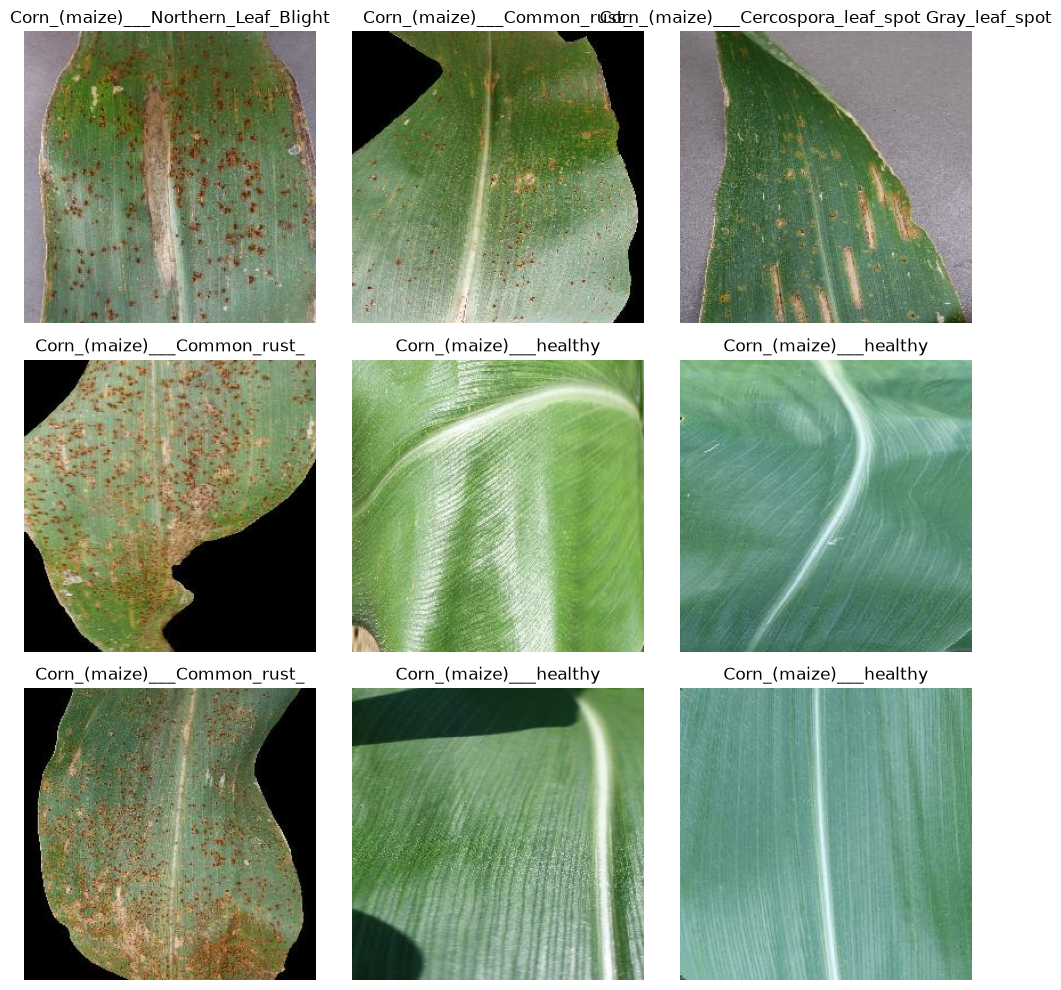

In [ ]:

# 3. Data Sanity Check


plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:

# 4. Pipeline Optimization


train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:

# 5. Model Architecture


model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Preprocessing & Data Augmentation
    layers.Rescaling(1.0 / 255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),

    # Feature Extractor
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Classification Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:

# 6. Training


os.makedirs('logs', exist_ok=True)
os.makedirs('models', exist_ok=True)

training_callbacks = [
    callbacks.TensorBoard(log_dir='logs'),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,               # Give it 10 epochs before giving up
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1                  # Logs when the learning rate drops
    )
]

history = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    callbacks=training_callbacks
)

Epoch 1/25


/home/pranay/ml_workspace/ml-env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1790934256.397886    7300 cuda_dnn.cc:461] Loaded cuDNN version 92600


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8303 - loss: 0.4523

W0000 00:00:1790934278.684584    7763 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


97/97 ━━━━━━━━━━━━━━━━━━━━ 34s 131ms/step - accuracy: 0.8303 - loss: 0.4523 - val_accuracy: 0.2358 - val_loss: 1.3910 - learning_rate: 3.0000e-04
Epoch 2/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.8822 - loss: 0.2876 - val_accuracy: 0.2358 - val_loss: 1.4358 - learning_rate: 3.0000e-04
Epoch 3/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.8958 - loss: 0.2558 - val_accuracy: 0.5959 - val_loss: 0.9578 - learning_rate: 3.0000e-04
Epoch 4/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.9082 - loss: 0.2359 - val_accuracy: 0.7306 - val_loss: 0.7563 - learning_rate: 3.0000e-04
Epoch 5/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.9153 - loss: 0.2149 - val_accuracy: 0.8756 - val_loss: 0.3207 - learning_rate: 3.0000e-04
Epoch 6/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.9238 - loss: 0.1950 - val_accuracy: 0.9301 - val_loss: 0.1688 - learning_rate: 3.0000e-04
Epoch 7/25
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.9263 -

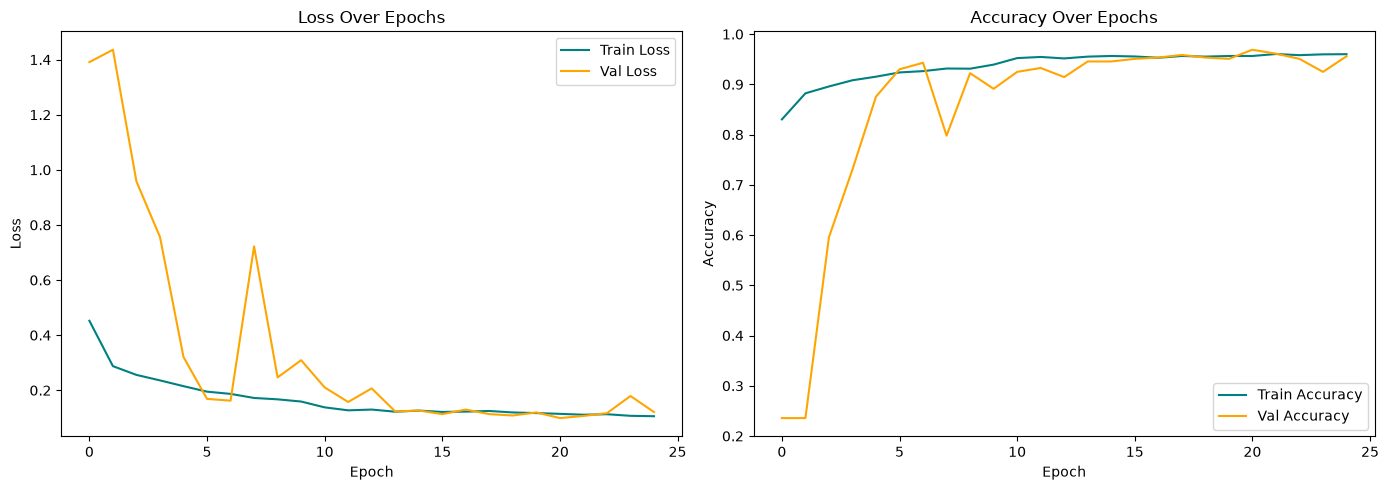

In [ ]:

# 7. Training Visualizations


import os
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'], label='Train Loss', color='teal')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='teal')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()

# Save the figure before showing it
os.makedirs('reports/figures', exist_ok=True)
fig.savefig('reports/figures/corn_training_performance.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:

# 8. Test Set Evaluation & Export (Markdown Log)


import os
from datetime import datetime
from sklearn.metrics import classification_report

test_loss, test_acc = model.evaluate(test_ds)

# Collect predictions
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

report_text = classification_report(
    y_true, 
    y_pred, 
    target_names=class_names,
    zero_division=0
)

# Append to evaluation_summary.md
os.makedirs('reports', exist_ok=True)
log_path = os.path.join('reports', 'evaluation_summary.md')

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
dataset_name = os.path.basename(os.path.normpath(DATA_DIR))

with open(log_path, 'a') as f:
    f.write(f"\n## Evaluation Run: {dataset_name} ({timestamp})\n")
    f.write(f"- **Overall Test Loss:** {test_loss:.4f}\n")
    f.write(f"- **Overall Test Accuracy:** {test_acc * 100:.2f}%\n\n")
    f.write("```text\n")
    f.write(report_text)
    f.write("\n```\n")
    f.write("---\n")

print(f"Appended run results to {log_path}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9766 - loss: 0.0724
Appended run results to reports/evaluation_summary.md


In [10]:
model_path = os.path.join('models', 'corn_classifier.keras')
model.save(model_path)
print(f"Model saved to {model_path}")

Model saved to models/corn_classifier.keras


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Predicted Condition: Corn_(maize)___Common_rust_ (100.00% confidence)


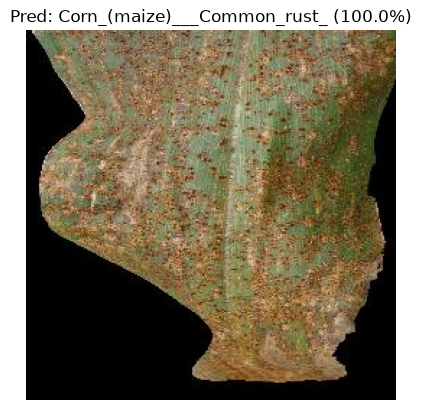

In [ ]:

# 9. Single Image Inference


loaded_model = tf.keras.models.load_model(model_path)

import random

random_class = random.choice(class_names)


# Pick an arbitrary sample leaf
sample_image_path = os.path.join(DATA_DIR, random_class, random.choice(os.listdir(os.path.join(DATA_DIR, random_class))))

# Read and format
img = cv2.imread(sample_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
resized_img = cv2.resize(img, IMG_SIZE)
input_tensor = np.expand_dims(resized_img, axis=0)

# Predict
predictions = loaded_model.predict(input_tensor)
predicted_class = class_names[np.argmax(predictions[0])]
confidence = np.max(predictions[0]) * 100

print(f"Predicted Condition: {predicted_class} ({confidence:.2f}% confidence)")

# Display image with predicted label
plt.imshow(img)
plt.title(f"Pred: {predicted_class} ({confidence:.1f}%)")
plt.axis("off")
plt.show()